# 02 — Synthetic Primary Analysis (DR-RF)

Generates primary manuscript figures and tables using **DR-RF only**.

Sections:
1. Load results for all alpha values
2. DR-RF scissors chart — ATE MSE vs alpha (5 methods, 95% CI bands)
3. DR-RF scissors chart — CATE MSE vs alpha
4. Paired-difference table per alpha
5. Ranking metrics (alpha > 0)
6. Summary table for paper

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
REVISED_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for p in [PROJECT_ROOT, REVISED_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.join(REVISED_ROOT, 'synthetic'))
import config as CFG

from helpers.runner import load_checkpoint
from helpers.metrics import (
    METHODS_ORDER, LEARNERS_ORDER, paired_ci, ranking_comparison_table, format_ci,
    resolve_alternative, describe_paired_test, build_paper_summary_table_by_alpha, significance_stars
)
from helpers.plotting import plot_scissors_chart, METHOD_LABELS

os.makedirs(CFG.PLOTS_DIR, exist_ok=True)
print(f'Setup complete. CI_METHOD={CFG.CI_METHOD!r}, CI_SIDED={CFG.CI_SIDED!r}')


Setup complete. CI_METHOD='bootstrap', CI_SIDED='two-sided'


## 1. Load Results for All Alpha Values

In [2]:
results_by_alpha = {}
for alpha in CFG.ALPHA_VALUES:
    full_path = CFG.CHECKPOINT_PATH_TEMPLATE.format(alpha=alpha)
    debug_path = CFG.CHECKPOINT_PATH_TEMPLATE.format(alpha=alpha)
    if os.path.exists(full_path):
        path = full_path
    else:
        path = debug_path
        print(f'WARNING: full-scale checkpoint not found for alpha={alpha:.2f}; '
              f'falling back to DEBUG checkpoint (small N_TRAIN/N_TEST, few seeds). '
              f'Run the full loop in 01_experiment.ipynb for real results.')
    results_by_alpha[alpha] = load_checkpoint(path)
    print(f'alpha={alpha:.2f}: {len(results_by_alpha[alpha])} seeds  [{os.path.basename(path)}]')


alpha=0.00: 20 seeds  [results_alpha_0.00.pkl]
alpha=0.25: 20 seeds  [results_alpha_0.25.pkl]
alpha=0.50: 20 seeds  [results_alpha_0.50.pkl]
alpha=0.75: 20 seeds  [results_alpha_0.75.pkl]
alpha=1.00: 20 seeds  [results_alpha_1.00.pkl]


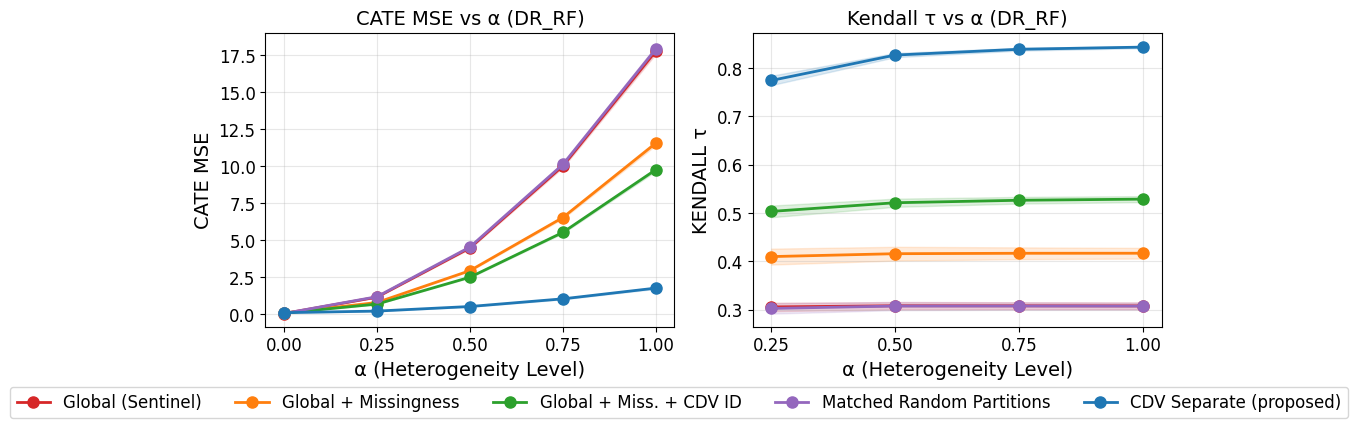

In [3]:
from helpers.plotting import plot_scissors_chart_combined

fig = plot_scissors_chart_combined(
    results_by_alpha,
    panels=[
        {'metric': 'cate_mse', 'alpha_values': CFG.ALPHA_VALUES,
         'title': f'CATE MSE vs α ({CFG.PRIMARY_LEARNER})'},
        {'metric': 'kendall_tau', 'alpha_values': [a for a in CFG.ALPHA_VALUES if a > 0],
         'title': f'Kendall τ vs α ({CFG.PRIMARY_LEARNER})'},
    ],
    learner=CFG.PRIMARY_LEARNER,
    save_path=os.path.join(CFG.PLOTS_DIR, 'combined_cate_kendall.png'),
)
plt.show()


## 2. DR-RF Scissors Chart — ATE MSE vs Alpha

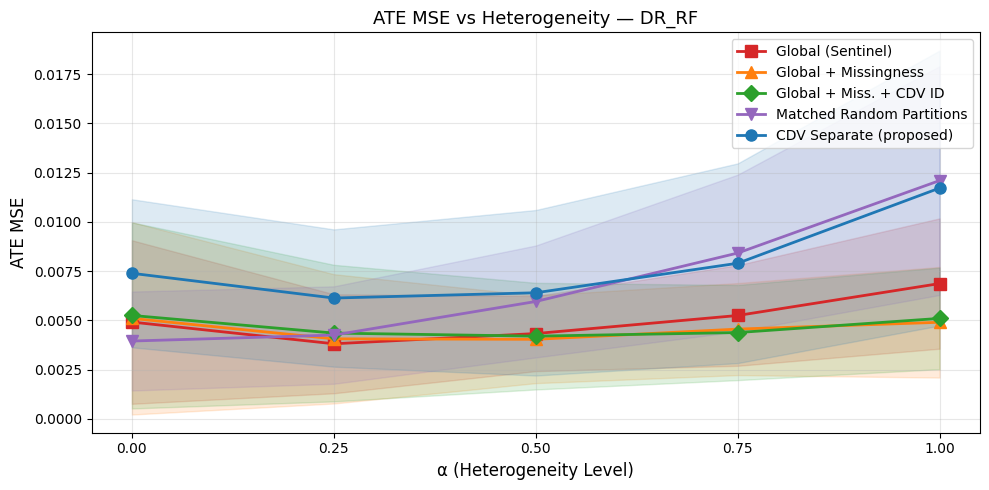

In [4]:
fig = plot_scissors_chart(
    results_by_alpha,
    alpha_values=CFG.ALPHA_VALUES,
    learner=CFG.PRIMARY_LEARNER,
    metric='ate_mse',
    title=f'ATE MSE vs Heterogeneity — {CFG.PRIMARY_LEARNER}',
    save_path=os.path.join(CFG.PLOTS_DIR, 'scissors_ate_mse.png'),
)
plt.show()

## 3. DR-RF Scissors Chart — CATE MSE vs Alpha

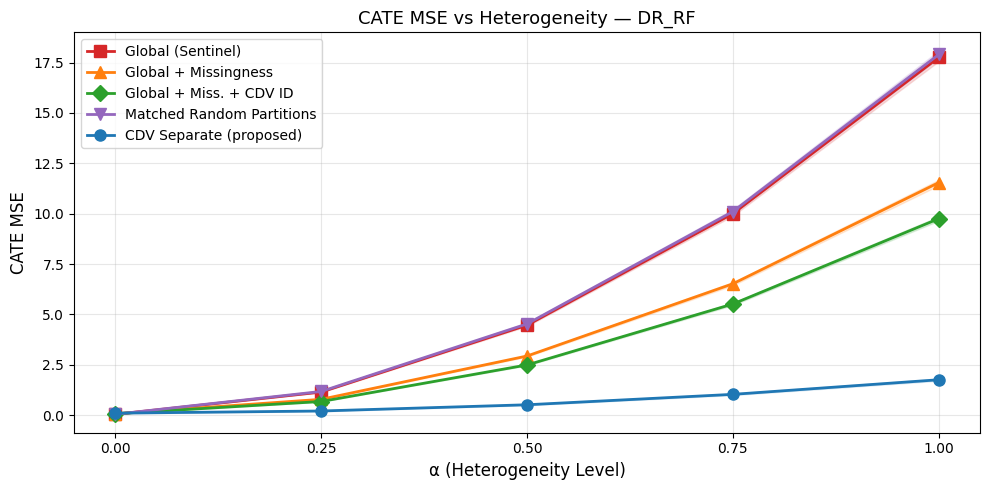

In [5]:
fig = plot_scissors_chart(
    results_by_alpha,
    alpha_values=CFG.ALPHA_VALUES,
    learner=CFG.PRIMARY_LEARNER,
    metric='cate_mse',
    title=f'CATE MSE vs Heterogeneity — {CFG.PRIMARY_LEARNER}',
    save_path=os.path.join(CFG.PLOTS_DIR, 'scissors_cate_mse.png'),
)
plt.show()

## 4. Paired Differences per Alpha (CDV_SEPARATE vs others)

In [6]:
alt_ate = resolve_alternative(CFG.CI_SIDED, lower_is_better=True)
print(describe_paired_test('CDV_SEPARATE', 'method', 'ATE MSE', lower_is_better=True,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))

rows = []
for alpha in CFG.ALPHA_VALUES:
    res = results_by_alpha.get(alpha, {})
    cdv_vals = np.array([
        sr['metrics'].get('CDV_SEPARATE', {}).get(CFG.PRIMARY_LEARNER, {}).get('ate_mse', np.nan)
        for sr in res.values()
    ])
    for method in METHODS_ORDER:
        if method == 'CDV_SEPARATE':
            continue
        other_vals = np.array([
            sr['metrics'].get(method, {}).get(CFG.PRIMARY_LEARNER, {}).get('ate_mse', np.nan)
            for sr in res.values()
        ])
        ci = paired_ci(cdv_vals, other_vals, method=CFG.CI_METHOD, alternative=alt_ate)
        rows.append({
            'alpha': alpha,
            'vs_method': METHOD_LABELS.get(method, method),
            'mean_delta': ci['mean'],
            'paired 95% CI of Δ (CDV_SEPARATE − method)': format_ci(ci['ci_lo'], ci['ci_hi'], decimals=5),
            'p_value (paired)': ci['p_value'],
            'n_seeds': ci['n'],
        })

diff_df = pd.DataFrame(rows)
display(diff_df.round(5))
diff_df.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'paired_differences.csv'), index=False)


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (ATE MSE), paired per outer seed. H1: Δ ≠ 0.


,alpha,vs_method,mean_delta,paired 95% CI of Δ (CDV_SEPARATE − method),p_value (paired),n_seeds
0,0.00,Global (Sentinel),0.00247,"[-0.00084, 0.00602]",0.1480,20
1,0.00,Global + Missingness,0.00229,"[-0.00168, 0.00626]",0.2448,20
2,0.00,Global + Miss. + CDV ID,0.00214,"[-0.00163, 0.00599]",0.2522,20
3,0.00,Matched Random Partitions,0.00344,"[0.00058, 0.00671]",0.0172,20
4,0.25,Global (Sentinel),0.00232,"[-0.00024, 0.00488]",0.0762,20
5,0.25,Global + Missingness,0.00207,"[-0.00039, 0.00463]",0.0968,20
6,0.25,Global + Miss. + CDV ID,0.00178,"[-0.00048, 0.00420]",0.1278,20
7,0.25,Matched Random Partitions,0.00188,"[-0.00145, 0.00553]",0.3086,20
8,0.50,Global (Sentinel),0.00207,"[-0.00170, 0.00614]",0.3094,20
9,0.50,Global + Missingness,0.00236,"[-0.00034, 0.00536]",0.0908,20


## 4b. Paired Differences per Alpha — CATE (CDV_SEPARATE vs others)

In [7]:
alt_cate = resolve_alternative(CFG.CI_SIDED, lower_is_better=True)
print(describe_paired_test('CDV_SEPARATE', 'method', 'CATE MSE', lower_is_better=True,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))

rows_cate = []
for alpha in CFG.ALPHA_VALUES:
    res = results_by_alpha.get(alpha, {})
    cdv_vals = np.array([
        sr['metrics'].get('CDV_SEPARATE', {}).get(CFG.PRIMARY_LEARNER, {}).get('cate_mse', np.nan)
        for sr in res.values()
    ])
    for method in METHODS_ORDER:
        if method == 'CDV_SEPARATE':
            continue
        other_vals = np.array([
            sr['metrics'].get(method, {}).get(CFG.PRIMARY_LEARNER, {}).get('cate_mse', np.nan)
            for sr in res.values()
        ])
        ci = paired_ci(cdv_vals, other_vals, method=CFG.CI_METHOD, alternative=alt_cate)
        rows_cate.append({
            'alpha': alpha,
            'vs_method': METHOD_LABELS.get(method, method),
            'mean_delta': ci['mean'],
            'paired 95% CI of Δ (CDV_SEPARATE − method)': format_ci(ci['ci_lo'], ci['ci_hi'], decimals=5),
            'p_value (paired)': ci['p_value'],
            'n_seeds': ci['n'],
        })

diff_cate_df = pd.DataFrame(rows_cate)
display(diff_cate_df.round(5))
diff_cate_df.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'paired_differences_cate.csv'), index=False)


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (CATE MSE), paired per outer seed. H1: Δ ≠ 0.


,alpha,vs_method,mean_delta,paired 95% CI of Δ (CDV_SEPARATE − method),p_value (paired),n_seeds
0,0.00,Global (Sentinel),0.05816,"[0.04813, 0.06821]",0.0,20
1,0.00,Global + Missingness,0.02821,"[0.01463, 0.04149]",0.0,20
2,0.00,Global + Miss. + CDV ID,0.02624,"[0.01460, 0.03838]",0.0,20
3,0.00,Matched Random Partitions,0.05430,"[0.04348, 0.06446]",0.0,20
4,0.25,Global (Sentinel),-0.93892,"[-0.95574, -0.92261]",0.0,20
5,0.25,Global + Missingness,-0.57890,"[-0.59462, -0.56294]",0.0,20
6,0.25,Global + Miss. + CDV ID,-0.47060,"[-0.48628, -0.45418]",0.0,20
7,0.25,Matched Random Partitions,-0.96936,"[-0.98618, -0.95234]",0.0,20
8,0.50,Global (Sentinel),-3.94956,"[-3.99484, -3.90479]",0.0,20
9,0.50,Global + Missingness,-2.41970,"[-2.45523, -2.38346]",0.0,20


## 4c. DR-RF Scissors Chart — Kendall Tau vs Alpha

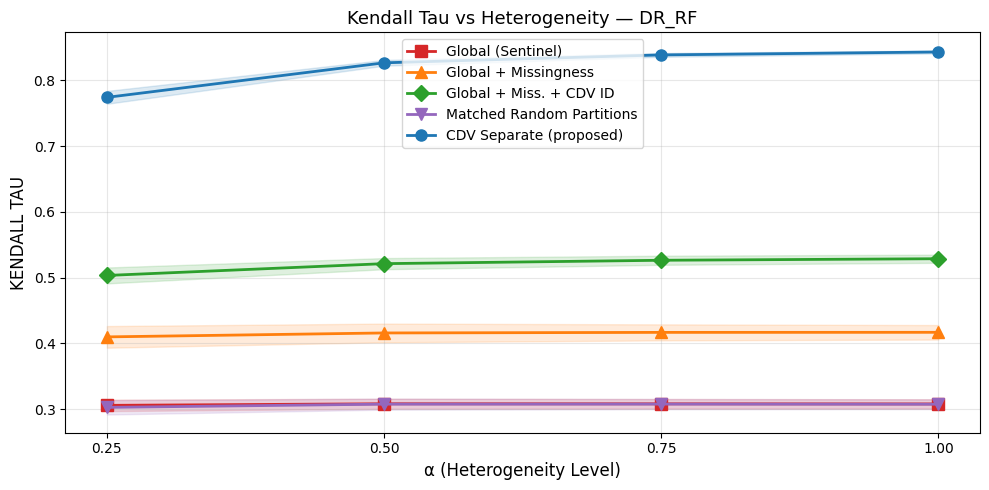

In [8]:
fig = plot_scissors_chart(
    results_by_alpha,
    alpha_values=[a for a in CFG.ALPHA_VALUES if a>0],
    learner=CFG.PRIMARY_LEARNER,
    metric='kendall_tau',
    title=f'Kendall Tau vs Heterogeneity — {CFG.PRIMARY_LEARNER}',
    save_path=os.path.join(CFG.PLOTS_DIR, 'scissors_kendall_tau.png'),
)
plt.show()

## 4d. DR-RF Scissors Chart — Spearman Rho vs Alpha

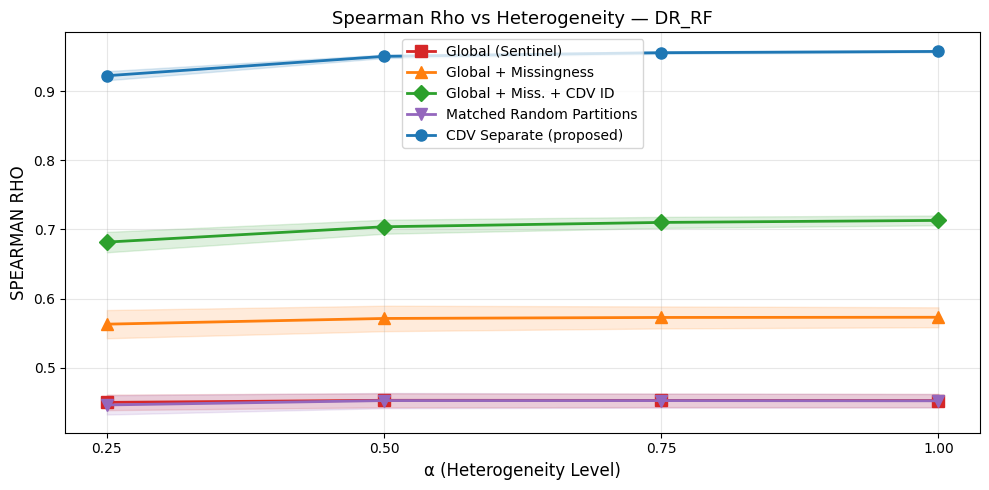

In [9]:
fig = plot_scissors_chart(
    results_by_alpha,
    alpha_values=[a for a in CFG.ALPHA_VALUES if a>0],
    learner=CFG.PRIMARY_LEARNER,
    metric='spearman_rho',
    title=f'Spearman Rho vs Heterogeneity — {CFG.PRIMARY_LEARNER}',
    save_path=os.path.join(CFG.PLOTS_DIR, 'scissors_spearman_rho.png'),
)
plt.show()

## 5. Ranking Metrics (alpha > 0)

In [10]:
print(f'Ranking Metrics ({CFG.PRIMARY_LEARNER}), alpha > 0 only')
print(describe_paired_test('CDV_SEPARATE', 'method', 'Kendall τ / Spearman ρ', lower_is_better=False,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))
rank_rows = []
for alpha in [a for a in CFG.ALPHA_VALUES if a > 0]:
    res = results_by_alpha.get(alpha, {})
    for method in METHODS_ORDER:
        tau_vals = [sr['metrics'].get(method, {}).get(CFG.PRIMARY_LEARNER, {}).get('kendall_tau', np.nan)
                    for sr in res.values()]
        rho_vals = [sr['metrics'].get(method, {}).get(CFG.PRIMARY_LEARNER, {}).get('spearman_rho', np.nan)
                    for sr in res.values()]
        rank_rows.append({
            'alpha': alpha, 'method': METHOD_LABELS.get(method, method),
            'kendall_tau_mean': np.nanmean(tau_vals), 'kendall_tau_std': np.nanstd(tau_vals),
            'spearman_rho_mean': np.nanmean(rho_vals), 'spearman_rho_std': np.nanstd(rho_vals),
        })

rank_df = pd.DataFrame(rank_rows)

# Paired 95% CI of Δ (CDV_SEPARATE − method), paired p-value, and improvement % vs CDV_SEPARATE; NaN for the CDV_SEPARATE row itself
cmp_rows = []
for alpha in [a for a in CFG.ALPHA_VALUES if a > 0]:
    res = results_by_alpha.get(alpha, {})
    tau_cmp = ranking_comparison_table(res, CFG.PRIMARY_LEARNER, metric='kendall_tau',
                                        ci_method=CFG.CI_METHOD, sided=CFG.CI_SIDED)
    rho_cmp = ranking_comparison_table(res, CFG.PRIMARY_LEARNER, metric='spearman_rho',
                                        ci_method=CFG.CI_METHOD, sided=CFG.CI_SIDED)
    for method in tau_cmp.index:
        cmp_rows.append({
            'alpha': alpha, 'method': METHOD_LABELS.get(method, method),
            'kendall_tau_paired_95%_CI': tau_cmp.loc[method, 'paired 95% CI of Δ (CDV_SEPARATE − method)'],
            'kendall_tau_p_value_paired': tau_cmp.loc[method, 'p_value (paired)'],
            'kendall_tau_improvement_pct': tau_cmp.loc[method, 'improvement_pct'],
            'spearman_rho_paired_95%_CI': rho_cmp.loc[method, 'paired 95% CI of Δ (CDV_SEPARATE − method)'],
            'spearman_rho_p_value_paired': rho_cmp.loc[method, 'p_value (paired)'],
            'spearman_rho_improvement_pct': rho_cmp.loc[method, 'improvement_pct'],
        })

rank_df = rank_df.merge(pd.DataFrame(cmp_rows), on=['alpha', 'method'], how='left')
display(rank_df.round(4))


Ranking Metrics (DR_RF), alpha > 0 only
paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (Kendall τ / Spearman ρ), paired per outer seed. H1: Δ ≠ 0.


,alpha,method,kendall_tau_mean,kendall_tau_std,spearman_rho_mean,spearman_rho_std,kendall_tau_paired_95%_CI,kendall_tau_p_value_paired,kendall_tau_improvement_pct,spearman_rho_paired_95%_CI,spearman_rho_p_value_paired,spearman_rho_improvement_pct
0,0.25,Global (Sentinel),0.3056,0.0182,0.4500,0.0234,"[0.4550, 0.4815]",0.0,153.2721,"[0.4600, 0.4847]",0.0,104.9791
1,0.25,Global + Missingness,0.4098,0.0343,0.5631,0.0425,"[0.3464, 0.3815]",0.0,88.9039,"[0.3397, 0.3788]",0.0,63.8003
2,0.25,Global + Miss. + CDV ID,0.5032,0.0252,0.6818,0.0307,"[0.2563, 0.2854]",0.0,53.8274,"[0.2259, 0.2560]",0.0,35.2881
3,0.25,Matched Random Partitions,0.3025,0.0226,0.4463,0.0288,"[0.4570, 0.4860]",0.0,155.8626,"[0.4617, 0.4907]",0.0,106.6839
4,0.25,CDV Separate (proposed),0.7741,0.0204,0.9223,0.0138,NaN,NaN,NaN,NaN,NaN,NaN
5,0.50,Global (Sentinel),0.3080,0.0159,0.4530,0.0210,"[0.5101, 0.5271]",0.0,168.3471,"[0.4881, 0.5068]",0.0,109.7969
6,0.50,Global + Missingness,0.4158,0.0296,0.5713,0.0384,"[0.3974, 0.4247]",0.0,98.8239,"[0.3624, 0.3964]",0.0,66.3379
7,0.50,Global + Miss. + CDV ID,0.5212,0.0176,0.7039,0.0211,"[0.2962, 0.3148]",0.0,58.6145,"[0.2370, 0.2565]",0.0,35.0045
8,0.50,Matched Random Partitions,0.3075,0.0175,0.4526,0.0230,"[0.5100, 0.5283]",0.0,168.8245,"[0.4877, 0.5081]",0.0,109.9850
9,0.50,CDV Separate (proposed),0.8266,0.0091,0.9504,0.0052,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Summary Table for Paper

In [11]:
summary_rows = []
for alpha in CFG.ALPHA_VALUES:
    res = results_by_alpha.get(alpha, {})
    for method in METHODS_ORDER:
        ate_vals  = [sr['metrics'].get(method, {}).get(CFG.PRIMARY_LEARNER, {}).get('ate_mse', np.nan)  for sr in res.values()]
        cate_vals = [sr['metrics'].get(method, {}).get(CFG.PRIMARY_LEARNER, {}).get('cate_mse', np.nan) for sr in res.values()]
        summary_rows.append({
            'alpha': alpha, 'method': method,
            'ate_mse_mean': np.nanmean(ate_vals), 'ate_mse_std': np.nanstd(ate_vals),
            'cate_mse_mean': np.nanmean(cate_vals), 'cate_mse_std': np.nanstd(cate_vals),
            'n_seeds': int(np.sum(np.isfinite(ate_vals))),
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(5))
summary_df.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'primary_summary.csv'), index=False)
print(f'Saved: {CFG.ARTIFACTS_DIR}/primary_summary.csv')

,alpha,method,ate_mse_mean,ate_mse_std,cate_mse_mean,cate_mse_std,n_seeds
0,0.00,GLOBAL_SENTINEL,0.00492,0.00864,0.04196,0.01855,20
1,0.00,GLOBAL_MISSINGNESS,0.00511,0.01017,0.07192,0.02603,20
2,0.00,GLOBAL_MISSINGNESS_CDV,0.00525,0.00984,0.07389,0.02478,20
3,0.00,MATCHED_RANDOM_PARTITIONS,0.00396,0.00523,0.04583,0.02129,20
4,0.00,CDV_SEPARATE,0.00739,0.00783,0.10013,0.03050,20
5,0.25,GLOBAL_SENTINEL,0.00382,0.00523,1.14720,0.03402,20
6,0.25,GLOBAL_MISSINGNESS,0.00407,0.00683,0.78717,0.03056,20
7,0.25,GLOBAL_MISSINGNESS_CDV,0.00436,0.00722,0.67887,0.02908,20
8,0.25,MATCHED_RANDOM_PARTITIONS,0.00426,0.00515,1.17764,0.04179,20
9,0.25,CDV_SEPARATE,0.00614,0.00726,0.20828,0.03606,20


Saved: cdv_experiments/synthetic/artifacts/primary_summary.csv


## 7. Compact Paper Summary Tables (all alpha values, with significance)

The full per-alpha breakdown (Sections 4–5) is too wide for the paper. These
compact tables put **alpha values as columns** instead: row index is
(Metric, Method); the CDV_SEPARATE row shows its own raw mean ± std per alpha
(reference); every other method's cell shows the paired
Δ = CDV_SEPARATE − method (mean) with significance stars from the same paired
test, e.g. `-0.938***` (see `CFG.CI_METHOD` / `CFG.CI_SIDED`).
Significance: `*` p<0.1, `**` p<0.05, `***` p<0.01, `-` not significant / no data.


In [12]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'ATE/CATE MSE', lower_is_better=True,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))

ate_cate_by_alpha = build_paper_summary_table_by_alpha(
    results_by_alpha,
    learner=CFG.PRIMARY_LEARNER,
    alpha_values=CFG.ALPHA_VALUES,
    metrics=['ate_mse', 'cate_mse'],
    metric_labels={'ate_mse': 'ATE MSE', 'cate_mse': 'CATE MSE'},
    method_labels=METHOD_LABELS,
    lower_is_better={'ate_mse': True, 'cate_mse': True},
    ci_method=CFG.CI_METHOD,
    sided=CFG.CI_SIDED,
)
display(ate_cate_by_alpha)
ate_cate_by_alpha.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'paper_summary_ate_cate_by_alpha.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (ATE/CATE MSE), paired per outer seed. H1: Δ ≠ 0.


α=0.00              α=0.25  \
Metric   Method                                                             
ATE MSE  CDV Separate (proposed)        0.007 ± 0.008       0.006 ± 0.007   
         Global (Sentinel)           0.002 ± 0.008 ns     0.002 ± 0.006 *   
         Global + Missingness        0.002 ± 0.009 ns     0.002 ± 0.006 *   
         Global + Miss. + CDV ID     0.002 ± 0.009 ns    0.002 ± 0.005 ns   
         Matched Random Partitions   0.003 ± 0.007 **    0.002 ± 0.008 ns   
CATE MSE CDV Separate (proposed)        0.100 ± 0.030       0.208 ± 0.036   
         Global (Sentinel)          0.058 ± 0.024 ***  -0.939 ± 0.039 ***   
         Global + Missingness       0.028 ± 0.031 ***  -0.579 ± 0.037 ***   
         Global + Miss. + CDV ID    0.026 ± 0.028 ***  -0.471 ± 0.038 ***   
         Matched Random Partitions  0.054 ± 0.024 ***  -0.969 ± 0.040 ***   

                                                α=0.50              α=0.75  \
Metric   Method                                                              
ATE MSE  CDV Separate (proposed)         0.006 ± 0.009       0.008 ± 0.011   
         Global (Sentinel)            0.002 ± 0.009 ns    0.003 ± 0.012 ns   
         Global + Missingness          0.002 ± 0.007 *     0.003 ± 0.010 *   
         Global + Miss. + CDV ID       0.002 ± 0.006 *    0.004 ± 0.009 **   
         Matched Random Partitions    0.000 ± 0.012 ns   -0.001 ± 0.016 ns   
CATE MSE CDV Separate (proposed)         0.517 ± 0.049       1.034 ± 0.074   
         Global (Sentinel)          -3.950 ± 0.106 ***  -8.969 ± 0.224 ***   
         Global + Missingness       -2.420 ± 0.084 ***  -5.488 ± 0.167 ***   
         Global + Miss. + CDV ID    -1.977 ± 0.080 ***  -4.485 ± 0.148 ***   
         Matched Random Partitions  -4.013 ± 0.117 ***  -9.071 ± 0.232 ***   

                                                 α=1.00  
Metric   Method                                          
ATE MSE  CDV Separate (proposed)          0.012 ± 0.015  
         Global (Sentinel)             0.005 ± 0.017 ns  
         Global + Missingness          0.007 ± 0.015 **  
         Global + Miss. + CDV ID      0.007 ± 0.013 ***  
         Matched Random Partitions    -0.000 ± 0.021 ns  
CATE MSE CDV Separate (proposed)          1.759 ± 0.103  
         Global (Sentinel)          -15.998 ± 0.388 ***  
         Global + Missingness        -9.784 ± 0.286 ***  
         Global + Miss. + CDV ID     -7.995 ± 0.243 ***  
         Matched Random Partitions  -16.142 ± 0.390 ***

In [13]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'Kendall τ / Spearman ρ', lower_is_better=False,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))

rank_by_alpha = build_paper_summary_table_by_alpha(
    results_by_alpha,
    learner=CFG.PRIMARY_LEARNER,
    alpha_values=[a for a in CFG.ALPHA_VALUES if a > 0],
    metrics=['kendall_tau', 'spearman_rho'],
    metric_labels={'kendall_tau': 'Kendall τ', 'spearman_rho': 'Spearman ρ'},
    method_labels=METHOD_LABELS,
    lower_is_better={'kendall_tau': False, 'spearman_rho': False},
    ci_method=CFG.CI_METHOD,
    sided=CFG.CI_SIDED,
)
display(rank_by_alpha)
rank_by_alpha.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'paper_summary_kendall_spearman_by_alpha.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (Kendall τ / Spearman ρ), paired per outer seed. H1: Δ ≠ 0.


α=0.25             α=0.50  \
Metric     Method                                                            
Kendall τ  CDV Separate (proposed)        0.774 ± 0.020      0.827 ± 0.009   
           Global (Sentinel)          0.468 ± 0.031 ***  0.519 ± 0.020 ***   
           Global + Missingness       0.364 ± 0.041 ***  0.411 ± 0.031 ***   
           Global + Miss. + CDV ID    0.271 ± 0.034 ***  0.305 ± 0.021 ***   
           Matched Random Partitions  0.472 ± 0.034 ***  0.519 ± 0.021 ***   
Spearman ρ CDV Separate (proposed)        0.922 ± 0.014      0.950 ± 0.005   
           Global (Sentinel)          0.472 ± 0.029 ***  0.497 ± 0.022 ***   
           Global + Missingness       0.359 ± 0.046 ***  0.379 ± 0.040 ***   
           Global + Miss. + CDV ID    0.241 ± 0.035 ***  0.246 ± 0.023 ***   
           Matched Random Partitions  0.476 ± 0.034 ***  0.498 ± 0.024 ***   

                                                 α=0.75             α=1.00  
Metric     Method                                                           
Kendall τ  CDV Separate (proposed)        0.839 ± 0.006      0.843 ± 0.005  
           Global (Sentinel)          0.531 ± 0.017 ***  0.535 ± 0.015 ***  
           Global + Missingness       0.422 ± 0.026 ***  0.426 ± 0.023 ***  
           Global + Miss. + CDV ID    0.312 ± 0.017 ***  0.314 ± 0.014 ***  
           Matched Random Partitions  0.531 ± 0.018 ***  0.536 ± 0.016 ***  
Spearman ρ CDV Separate (proposed)        0.956 ± 0.003      0.957 ± 0.003  
           Global (Sentinel)          0.503 ± 0.020 ***  0.505 ± 0.020 ***  
           Global + Missingness       0.383 ± 0.034 ***  0.384 ± 0.031 ***  
           Global + Miss. + CDV ID    0.245 ± 0.018 ***  0.244 ± 0.015 ***  
           Matched Random Partitions  0.503 ± 0.022 ***  0.505 ± 0.020 ***

## 8. Compact Signed Summary Tables (metric as primary columns)

Two compact tables for the main text: rows = method (CDV_SEPARATE first,
reference); columns grouped first by **metric**, then by **alpha**, each with
two sub-columns: raw **Mean ± Std** and a **signed Δ%** vs CDV_SEPARATE
(positive always means CDV_SEPARATE is better, regardless of metric
direction) with significance stars from a two-sided paired test (see
`CFG.CI_METHOD`). Table 8a covers ATE/CATE MSE (all alpha); Table 8b covers
Kendall τ / Spearman ρ (alpha > 0 only, undefined at alpha=0).
Significance: `*` p<0.1, `**` p<0.05, `***` p<0.01, `-` no data.

In [14]:
from helpers.metrics import build_signed_summary_table_by_alpha

print(describe_paired_test('CDV_SEPARATE', 'method', 'ATE/CATE MSE', lower_is_better=True,
                            sided='two-sided', ci_method=CFG.CI_METHOD))

signed_ate_cate_by_alpha = build_signed_summary_table_by_alpha(
    results_by_alpha,
    learner=CFG.PRIMARY_LEARNER,
    alpha_values=CFG.ALPHA_VALUES,
    metrics=['ate_mse', 'cate_mse'],
    metric_labels={'ate_mse': 'ATE MSE', 'cate_mse': 'CATE MSE'},
    method_labels=METHOD_LABELS,
    lower_is_better={'ate_mse': True, 'cate_mse': True},
    ci_method=CFG.CI_METHOD,
    sided='two-sided',
)
display(signed_ate_cate_by_alpha)
signed_ate_cate_by_alpha.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'signed_summary_ate_cate_by_alpha.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (ATE/CATE MSE), paired per outer seed. H1: Δ ≠ 0.


Metric                           ATE MSE                                \
alpha                               0.00           0.25           0.50   
                              Mean ± Std     Mean ± Std     Mean ± Std   
Global (Sentinel)          0.005 ± 0.009  0.004 ± 0.005  0.004 ± 0.004   
Global + Missingness       0.005 ± 0.010  0.004 ± 0.007  0.004 ± 0.005   
Global + Miss. + CDV ID    0.005 ± 0.010  0.004 ± 0.007  0.004 ± 0.006   
Matched Random Partitions  0.004 ± 0.005  0.004 ± 0.005  0.006 ± 0.006   
CDV Separate (proposed)    0.007 ± 0.008  0.006 ± 0.007  0.006 ± 0.009   

Metric                                                        CATE MSE  \
alpha                               0.75           1.00           0.00   
                              Mean ± Std     Mean ± Std     Mean ± Std   
Global (Sentinel)          0.005 ± 0.005  0.007 ± 0.007  0.042 ± 0.019   
Global + Missingness       0.005 ± 0.005  0.005 ± 0.006  0.072 ± 0.026   
Global + Miss. + CDV ID    0.004 ± 0.005  0.005 ± 0.005  0.074 ± 0.025   
Matched Random Partitions  0.008 ± 0.008  0.012 ± 0.012  0.046 ± 0.021   
CDV Separate (proposed)    0.008 ± 0.011  0.012 ± 0.015  0.100 ± 0.030   

Metric                                                                   \
alpha                               0.25           0.50            0.75   
                              Mean ± Std     Mean ± Std      Mean ± Std   
Global (Sentinel)          1.147 ± 0.034  4.466 ± 0.103  10.003 ± 0.226   
Global + Missingness       0.787 ± 0.031  2.937 ± 0.074   6.522 ± 0.164   
Global + Miss. + CDV ID    0.679 ± 0.029  2.493 ± 0.058   5.519 ± 0.124   
Matched Random Partitions  1.178 ± 0.042  4.530 ± 0.117  10.106 ± 0.236   
CDV Separate (proposed)    0.208 ± 0.036  0.517 ± 0.049   1.034 ± 0.074   

Metric                                      ATE MSE                      \
alpha                                1.00      0.00      0.25      0.50   
                               Mean ± Std Δ% (sig.) Δ% (sig.) Δ% (sig.)   
Global (Sentinel)          17.757 ± 0.399  -50.3%ns   -60.8%*  -47.8%ns   
Global + Missingness       11.543 ± 0.293  -44.8%ns   -50.9%*   -58.4%*   
Global + Miss. + CDV ID     9.754 ± 0.217  -40.7%ns  -40.8%ns   -52.4%*   
Matched Random Partitions  17.901 ± 0.405  -86.9%**  -44.1%ns   -7.4%ns   
CDV Separate (proposed)     1.759 ± 0.103         —         —         —   

Metric                                             CATE MSE             \
alpha                          0.75        1.00        0.00       0.25   
                          Δ% (sig.)   Δ% (sig.)   Δ% (sig.)  Δ% (sig.)   
Global (Sentinel)          -50.5%ns    -70.5%ns  -138.6%***  +81.8%***   
Global + Missingness        -73.3%*   -138.8%**   -39.2%***  +73.5%***   
Global + Miss. + CDV ID    -80.2%**  -129.6%***   -35.5%***  +69.3%***   
Matched Random Partitions   +6.2%ns     +3.1%ns  -118.5%***  +82.3%***   
CDV Separate (proposed)           —           —           —          —   

Metric                                                      
alpha                           0.50       0.75       1.00  
                           Δ% (sig.)  Δ% (sig.)  Δ% (sig.)  
Global (Sentinel)          +88.4%***  +89.7%***  +90.1%***  
Global + Missingness       +82.4%***  +84.1%***  +84.8%***  
Global + Miss. + CDV ID    +79.3%***  +81.3%***  +82.0%***  
Matched Random Partitions  +88.6%***  +89.8%***  +90.2%***  
CDV Separate (proposed)            —          —          —

In [15]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'Kendall τ / Spearman ρ', lower_is_better=False,
                            sided='two-sided', ci_method=CFG.CI_METHOD))

signed_rank_by_alpha = build_signed_summary_table_by_alpha(
    results_by_alpha,
    learner=CFG.PRIMARY_LEARNER,
    alpha_values=[a for a in CFG.ALPHA_VALUES if a > 0],
    metrics=['kendall_tau', 'spearman_rho'],
    metric_labels={'kendall_tau': 'Kendall τ', 'spearman_rho': 'Spearman ρ'},
    method_labels=METHOD_LABELS,
    lower_is_better={'kendall_tau': False, 'spearman_rho': False},
    ci_method=CFG.CI_METHOD,
    sided='two-sided',
)
display(signed_rank_by_alpha)
signed_rank_by_alpha.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'signed_summary_kendall_spearman_by_alpha.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (Kendall τ / Spearman ρ), paired per outer seed. H1: Δ ≠ 0.


Metric                         Kendall τ                                \
alpha                               0.25           0.50           0.75   
                              Mean ± Std     Mean ± Std     Mean ± Std   
Global (Sentinel)          0.306 ± 0.018  0.308 ± 0.016  0.308 ± 0.015   
Global + Missingness       0.410 ± 0.034  0.416 ± 0.030  0.417 ± 0.025   
Global + Miss. + CDV ID    0.503 ± 0.025  0.521 ± 0.018  0.526 ± 0.014   
Matched Random Partitions  0.303 ± 0.023  0.308 ± 0.018  0.308 ± 0.016   
CDV Separate (proposed)    0.774 ± 0.020  0.827 ± 0.009  0.839 ± 0.006   

Metric                                       Spearman ρ                 \
alpha                               1.00           0.25           0.50   
                              Mean ± Std     Mean ± Std     Mean ± Std   
Global (Sentinel)          0.308 ± 0.015  0.450 ± 0.023  0.453 ± 0.021   
Global + Missingness       0.417 ± 0.023  0.563 ± 0.043  0.571 ± 0.038   
Global + Miss. + CDV ID    0.529 ± 0.013  0.682 ± 0.031  0.704 ± 0.021   
Matched Random Partitions  0.307 ± 0.015  0.446 ± 0.029  0.453 ± 0.023   
CDV Separate (proposed)    0.843 ± 0.005  0.922 ± 0.014  0.950 ± 0.005   

Metric                                                    Kendall τ  \
alpha                               0.75           1.00        0.25   
                              Mean ± Std     Mean ± Std   Δ% (sig.)   
Global (Sentinel)          0.453 ± 0.020  0.453 ± 0.020  +153.3%***   
Global + Missingness       0.573 ± 0.033  0.573 ± 0.030   +88.9%***   
Global + Miss. + CDV ID    0.710 ± 0.017  0.713 ± 0.015   +53.8%***   
Matched Random Partitions  0.453 ± 0.021  0.452 ± 0.020  +155.9%***   
CDV Separate (proposed)    0.956 ± 0.003  0.957 ± 0.003           —   

Metric                                                         Spearman ρ  \
alpha                            0.50        0.75        1.00        0.25   
                            Δ% (sig.)   Δ% (sig.)   Δ% (sig.)   Δ% (sig.)   
Global (Sentinel)          +168.3%***  +172.3%***  +173.9%***  +105.0%***   
Global + Missingness        +98.8%***  +101.3%***  +102.3%***   +63.8%***   
Global + Miss. + CDV ID     +58.6%***   +59.3%***   +59.5%***   +35.3%***   
Matched Random Partitions  +168.8%***  +172.7%***  +174.3%***  +106.7%***   
CDV Separate (proposed)             —           —           —           —   

Metric                                                         
alpha                            0.50        0.75        1.00  
                            Δ% (sig.)   Δ% (sig.)   Δ% (sig.)  
Global (Sentinel)          +109.8%***  +111.0%***  +111.6%***  
Global + Missingness        +66.3%***   +66.8%***   +67.1%***  
Global + Miss. + CDV ID     +35.0%***   +34.6%***   +34.3%***  
Matched Random Partitions  +110.0%***  +111.2%***  +111.7%***  
CDV Separate (proposed)             —           —           —

## 9. Multiplicity-Adjusted Summary Tables (FDR-BH correction)

Sections 7–8 each report a **raw, unadjusted** paired p-value per (metric,
method, alpha) cell — up to 4 non-reference methods × 6 alpha values per
metric, i.e. dozens of simultaneous pairwise comparisons — so the raw
significance stars there are optimistic (inflated false-positive rate under
multiple testing). The tables below repeat 7a/7b/8a/8b with p-values
adjusted for multiplicity using Benjamini-Hochberg (`adjust_method='fdr_bh'`,
controls the false discovery rate; see `helpers.metrics.adjust_pvalues`).
Each alpha is always its own family, never pooled across alpha; within an
alpha, ATE MSE, CATE MSE, Kendall τ, and Spearman ρ are each corrected as
their own separate family (`metric_families={}`) — 4 families per alpha.
Only the significance stars change here — means, CIs, and Δ% are identical
to the unadjusted tables above.

In [16]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'ATE/CATE MSE', lower_is_better=True,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD)
      + '  [stars: FDR-BH adjusted, ATE MSE and CATE MSE each their own family, per alpha]')

ate_cate_by_alpha_fdr = build_paper_summary_table_by_alpha(
    results_by_alpha,
    learner=CFG.PRIMARY_LEARNER,
    alpha_values=CFG.ALPHA_VALUES,
    metrics=['ate_mse', 'cate_mse'],
    metric_labels={'ate_mse': 'ATE MSE', 'cate_mse': 'CATE MSE'},
    method_labels=METHOD_LABELS,
    lower_is_better={'ate_mse': True, 'cate_mse': True},
    ci_method=CFG.CI_METHOD,
    sided=CFG.CI_SIDED,
    adjust_method='fdr_bh',
    metric_families={},
)
display(ate_cate_by_alpha_fdr)
ate_cate_by_alpha_fdr.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'paper_summary_ate_cate_by_alpha_fdr_bh.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (ATE/CATE MSE), paired per outer seed. H1: Δ ≠ 0.  [stars: FDR-BH adjusted, ATE MSE and CATE MSE each their own family, per alpha]


α=0.00              α=0.25  \
Metric   Method                                                             
ATE MSE  CDV Separate (proposed)        0.007 ± 0.008       0.006 ± 0.007   
         Global (Sentinel)           0.002 ± 0.008 ns    0.002 ± 0.006 ns   
         Global + Missingness        0.002 ± 0.009 ns    0.002 ± 0.006 ns   
         Global + Miss. + CDV ID     0.002 ± 0.009 ns    0.002 ± 0.005 ns   
         Matched Random Partitions    0.003 ± 0.007 *    0.002 ± 0.008 ns   
CATE MSE CDV Separate (proposed)        0.100 ± 0.030       0.208 ± 0.036   
         Global (Sentinel)          0.058 ± 0.024 ***  -0.939 ± 0.039 ***   
         Global + Missingness       0.028 ± 0.031 ***  -0.579 ± 0.037 ***   
         Global + Miss. + CDV ID    0.026 ± 0.028 ***  -0.471 ± 0.038 ***   
         Matched Random Partitions  0.054 ± 0.024 ***  -0.969 ± 0.040 ***   

                                                α=0.50              α=0.75  \
Metric   Method                                                              
ATE MSE  CDV Separate (proposed)         0.006 ± 0.009       0.008 ± 0.011   
         Global (Sentinel)            0.002 ± 0.009 ns    0.003 ± 0.012 ns   
         Global + Missingness         0.002 ± 0.007 ns    0.003 ± 0.010 ns   
         Global + Miss. + CDV ID      0.002 ± 0.006 ns    0.004 ± 0.009 ns   
         Matched Random Partitions    0.000 ± 0.012 ns   -0.001 ± 0.016 ns   
CATE MSE CDV Separate (proposed)         0.517 ± 0.049       1.034 ± 0.074   
         Global (Sentinel)          -3.950 ± 0.106 ***  -8.969 ± 0.224 ***   
         Global + Missingness       -2.420 ± 0.084 ***  -5.488 ± 0.167 ***   
         Global + Miss. + CDV ID    -1.977 ± 0.080 ***  -4.485 ± 0.148 ***   
         Matched Random Partitions  -4.013 ± 0.117 ***  -9.071 ± 0.232 ***   

                                                 α=1.00  
Metric   Method                                          
ATE MSE  CDV Separate (proposed)          0.012 ± 0.015  
         Global (Sentinel)             0.005 ± 0.017 ns  
         Global + Missingness          0.007 ± 0.015 **  
         Global + Miss. + CDV ID       0.007 ± 0.013 **  
         Matched Random Partitions    -0.000 ± 0.021 ns  
CATE MSE CDV Separate (proposed)          1.759 ± 0.103  
         Global (Sentinel)          -15.998 ± 0.388 ***  
         Global + Missingness        -9.784 ± 0.286 ***  
         Global + Miss. + CDV ID     -7.995 ± 0.243 ***  
         Matched Random Partitions  -16.142 ± 0.390 ***

In [17]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'Kendall τ / Spearman ρ', lower_is_better=False,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD)
      + '  [stars: FDR-BH adjusted, Kendall τ and Spearman ρ each their own family, per alpha]')

rank_by_alpha_fdr = build_paper_summary_table_by_alpha(
    results_by_alpha,
    learner=CFG.PRIMARY_LEARNER,
    alpha_values=[a for a in CFG.ALPHA_VALUES if a > 0],
    metrics=['kendall_tau', 'spearman_rho'],
    metric_labels={'kendall_tau': 'Kendall τ', 'spearman_rho': 'Spearman ρ'},
    method_labels=METHOD_LABELS,
    lower_is_better={'kendall_tau': False, 'spearman_rho': False},
    ci_method=CFG.CI_METHOD,
    sided=CFG.CI_SIDED,
    adjust_method='fdr_bh',
    metric_families={},
)
display(rank_by_alpha_fdr)
rank_by_alpha_fdr.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'paper_summary_kendall_spearman_by_alpha_fdr_bh.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (Kendall τ / Spearman ρ), paired per outer seed. H1: Δ ≠ 0.  [stars: FDR-BH adjusted, Kendall τ and Spearman ρ each their own family, per alpha]


α=0.25             α=0.50  \
Metric     Method                                                            
Kendall τ  CDV Separate (proposed)        0.774 ± 0.020      0.827 ± 0.009   
           Global (Sentinel)          0.468 ± 0.031 ***  0.519 ± 0.020 ***   
           Global + Missingness       0.364 ± 0.041 ***  0.411 ± 0.031 ***   
           Global + Miss. + CDV ID    0.271 ± 0.034 ***  0.305 ± 0.021 ***   
           Matched Random Partitions  0.472 ± 0.034 ***  0.519 ± 0.021 ***   
Spearman ρ CDV Separate (proposed)        0.922 ± 0.014      0.950 ± 0.005   
           Global (Sentinel)          0.472 ± 0.029 ***  0.497 ± 0.022 ***   
           Global + Missingness       0.359 ± 0.046 ***  0.379 ± 0.040 ***   
           Global + Miss. + CDV ID    0.241 ± 0.035 ***  0.246 ± 0.023 ***   
           Matched Random Partitions  0.476 ± 0.034 ***  0.498 ± 0.024 ***   

                                                 α=0.75             α=1.00  
Metric     Method                                                           
Kendall τ  CDV Separate (proposed)        0.839 ± 0.006      0.843 ± 0.005  
           Global (Sentinel)          0.531 ± 0.017 ***  0.535 ± 0.015 ***  
           Global + Missingness       0.422 ± 0.026 ***  0.426 ± 0.023 ***  
           Global + Miss. + CDV ID    0.312 ± 0.017 ***  0.314 ± 0.014 ***  
           Matched Random Partitions  0.531 ± 0.018 ***  0.536 ± 0.016 ***  
Spearman ρ CDV Separate (proposed)        0.956 ± 0.003      0.957 ± 0.003  
           Global (Sentinel)          0.503 ± 0.020 ***  0.505 ± 0.020 ***  
           Global + Missingness       0.383 ± 0.034 ***  0.384 ± 0.031 ***  
           Global + Miss. + CDV ID    0.245 ± 0.018 ***  0.244 ± 0.015 ***  
           Matched Random Partitions  0.503 ± 0.022 ***  0.505 ± 0.020 ***

In [18]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'ATE/CATE MSE', lower_is_better=True,
                            sided='two-sided', ci_method=CFG.CI_METHOD)
      + '  [stars: FDR-BH adjusted, ATE MSE and CATE MSE each their own family, per alpha]')

signed_ate_cate_by_alpha_fdr = build_signed_summary_table_by_alpha(
    results_by_alpha,
    learner=CFG.PRIMARY_LEARNER,
    alpha_values=CFG.ALPHA_VALUES,
    metrics=['ate_mse', 'cate_mse'],
    metric_labels={'ate_mse': 'ATE MSE', 'cate_mse': 'CATE MSE'},
    method_labels=METHOD_LABELS,
    lower_is_better={'ate_mse': True, 'cate_mse': True},
    ci_method=CFG.CI_METHOD,
    sided='two-sided',
    adjust_method='fdr_bh',
    metric_families={},
)
display(signed_ate_cate_by_alpha_fdr)
signed_ate_cate_by_alpha_fdr.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'signed_summary_ate_cate_by_alpha_fdr_bh.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (ATE/CATE MSE), paired per outer seed. H1: Δ ≠ 0.  [stars: FDR-BH adjusted, ATE MSE and CATE MSE each their own family, per alpha]


Metric                           ATE MSE                                \
alpha                               0.00           0.25           0.50   
                              Mean ± Std     Mean ± Std     Mean ± Std   
Global (Sentinel)          0.005 ± 0.009  0.004 ± 0.005  0.004 ± 0.004   
Global + Missingness       0.005 ± 0.010  0.004 ± 0.007  0.004 ± 0.005   
Global + Miss. + CDV ID    0.005 ± 0.010  0.004 ± 0.007  0.004 ± 0.006   
Matched Random Partitions  0.004 ± 0.005  0.004 ± 0.005  0.006 ± 0.006   
CDV Separate (proposed)    0.007 ± 0.008  0.006 ± 0.007  0.006 ± 0.009   

Metric                                                        CATE MSE  \
alpha                               0.75           1.00           0.00   
                              Mean ± Std     Mean ± Std     Mean ± Std   
Global (Sentinel)          0.005 ± 0.005  0.007 ± 0.007  0.042 ± 0.019   
Global + Missingness       0.005 ± 0.005  0.005 ± 0.006  0.072 ± 0.026   
Global + Miss. + CDV ID    0.004 ± 0.005  0.005 ± 0.005  0.074 ± 0.025   
Matched Random Partitions  0.008 ± 0.008  0.012 ± 0.012  0.046 ± 0.021   
CDV Separate (proposed)    0.008 ± 0.011  0.012 ± 0.015  0.100 ± 0.030   

Metric                                                                   \
alpha                               0.25           0.50            0.75   
                              Mean ± Std     Mean ± Std      Mean ± Std   
Global (Sentinel)          1.147 ± 0.034  4.466 ± 0.103  10.003 ± 0.226   
Global + Missingness       0.787 ± 0.031  2.937 ± 0.074   6.522 ± 0.164   
Global + Miss. + CDV ID    0.679 ± 0.029  2.493 ± 0.058   5.519 ± 0.124   
Matched Random Partitions  1.178 ± 0.042  4.530 ± 0.117  10.106 ± 0.236   
CDV Separate (proposed)    0.208 ± 0.036  0.517 ± 0.049   1.034 ± 0.074   

Metric                                      ATE MSE                      \
alpha                                1.00      0.00      0.25      0.50   
                               Mean ± Std Δ% (sig.) Δ% (sig.) Δ% (sig.)   
Global (Sentinel)          17.757 ± 0.399  -50.3%ns  -60.8%ns  -47.8%ns   
Global + Missingness       11.543 ± 0.293  -44.8%ns  -50.9%ns  -58.4%ns   
Global + Miss. + CDV ID     9.754 ± 0.217  -40.7%ns  -40.8%ns  -52.4%ns   
Matched Random Partitions  17.901 ± 0.405   -86.9%*  -44.1%ns   -7.4%ns   
CDV Separate (proposed)     1.759 ± 0.103         —         —         —   

Metric                                            CATE MSE             \
alpha                          0.75       1.00        0.00       0.25   
                          Δ% (sig.)  Δ% (sig.)   Δ% (sig.)  Δ% (sig.)   
Global (Sentinel)          -50.5%ns   -70.5%ns  -138.6%***  +81.8%***   
Global + Missingness       -73.3%ns  -138.8%**   -39.2%***  +73.5%***   
Global + Miss. + CDV ID    -80.2%ns  -129.6%**   -35.5%***  +69.3%***   
Matched Random Partitions   +6.2%ns    +3.1%ns  -118.5%***  +82.3%***   
CDV Separate (proposed)           —          —           —          —   

Metric                                                      
alpha                           0.50       0.75       1.00  
                           Δ% (sig.)  Δ% (sig.)  Δ% (sig.)  
Global (Sentinel)          +88.4%***  +89.7%***  +90.1%***  
Global + Missingness       +82.4%***  +84.1%***  +84.8%***  
Global + Miss. + CDV ID    +79.3%***  +81.3%***  +82.0%***  
Matched Random Partitions  +88.6%***  +89.8%***  +90.2%***  
CDV Separate (proposed)            —          —          —

In [19]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'Kendall τ / Spearman ρ', lower_is_better=False,
                            sided='two-sided', ci_method=CFG.CI_METHOD)
      + '  [stars: FDR-BH adjusted, Kendall τ and Spearman ρ each their own family, per alpha]')

signed_rank_by_alpha_fdr = build_signed_summary_table_by_alpha(
    results_by_alpha,
    learner=CFG.PRIMARY_LEARNER,
    alpha_values=[a for a in CFG.ALPHA_VALUES if a > 0],
    metrics=['kendall_tau', 'spearman_rho'],
    metric_labels={'kendall_tau': 'Kendall τ', 'spearman_rho': 'Spearman ρ'},
    method_labels=METHOD_LABELS,
    lower_is_better={'kendall_tau': False, 'spearman_rho': False},
    ci_method=CFG.CI_METHOD,
    sided='two-sided',
    adjust_method='fdr_bh',
    metric_families={},
)
display(signed_rank_by_alpha_fdr)
signed_rank_by_alpha_fdr.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'signed_summary_kendall_spearman_by_alpha_fdr_bh.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (Kendall τ / Spearman ρ), paired per outer seed. H1: Δ ≠ 0.  [stars: FDR-BH adjusted, Kendall τ and Spearman ρ each their own family, per alpha]


Metric                         Kendall τ                                \
alpha                               0.25           0.50           0.75   
                              Mean ± Std     Mean ± Std     Mean ± Std   
Global (Sentinel)          0.306 ± 0.018  0.308 ± 0.016  0.308 ± 0.015   
Global + Missingness       0.410 ± 0.034  0.416 ± 0.030  0.417 ± 0.025   
Global + Miss. + CDV ID    0.503 ± 0.025  0.521 ± 0.018  0.526 ± 0.014   
Matched Random Partitions  0.303 ± 0.023  0.308 ± 0.018  0.308 ± 0.016   
CDV Separate (proposed)    0.774 ± 0.020  0.827 ± 0.009  0.839 ± 0.006   

Metric                                       Spearman ρ                 \
alpha                               1.00           0.25           0.50   
                              Mean ± Std     Mean ± Std     Mean ± Std   
Global (Sentinel)          0.308 ± 0.015  0.450 ± 0.023  0.453 ± 0.021   
Global + Missingness       0.417 ± 0.023  0.563 ± 0.043  0.571 ± 0.038   
Global + Miss. + CDV ID    0.529 ± 0.013  0.682 ± 0.031  0.704 ± 0.021   
Matched Random Partitions  0.307 ± 0.015  0.446 ± 0.029  0.453 ± 0.023   
CDV Separate (proposed)    0.843 ± 0.005  0.922 ± 0.014  0.950 ± 0.005   

Metric                                                    Kendall τ  \
alpha                               0.75           1.00        0.25   
                              Mean ± Std     Mean ± Std   Δ% (sig.)   
Global (Sentinel)          0.453 ± 0.020  0.453 ± 0.020  +153.3%***   
Global + Missingness       0.573 ± 0.033  0.573 ± 0.030   +88.9%***   
Global + Miss. + CDV ID    0.710 ± 0.017  0.713 ± 0.015   +53.8%***   
Matched Random Partitions  0.453 ± 0.021  0.452 ± 0.020  +155.9%***   
CDV Separate (proposed)    0.956 ± 0.003  0.957 ± 0.003           —   

Metric                                                         Spearman ρ  \
alpha                            0.50        0.75        1.00        0.25   
                            Δ% (sig.)   Δ% (sig.)   Δ% (sig.)   Δ% (sig.)   
Global (Sentinel)          +168.3%***  +172.3%***  +173.9%***  +105.0%***   
Global + Missingness        +98.8%***  +101.3%***  +102.3%***   +63.8%***   
Global + Miss. + CDV ID     +58.6%***   +59.3%***   +59.5%***   +35.3%***   
Matched Random Partitions  +168.8%***  +172.7%***  +174.3%***  +106.7%***   
CDV Separate (proposed)             —           —           —           —   

Metric                                                         
alpha                            0.50        0.75        1.00  
                            Δ% (sig.)   Δ% (sig.)   Δ% (sig.)  
Global (Sentinel)          +109.8%***  +111.0%***  +111.6%***  
Global + Missingness        +66.3%***   +66.8%***   +67.1%***  
Global + Miss. + CDV ID     +35.0%***   +34.6%***   +34.3%***  
Matched Random Partitions  +110.0%***  +111.2%***  +111.7%***  
CDV Separate (proposed)             —           —           —

## 10. Combined Figure — CATE MSE & Kendall τ (side by side, shared legend)

Single figure with two panels sharing one legend, for the manuscript.


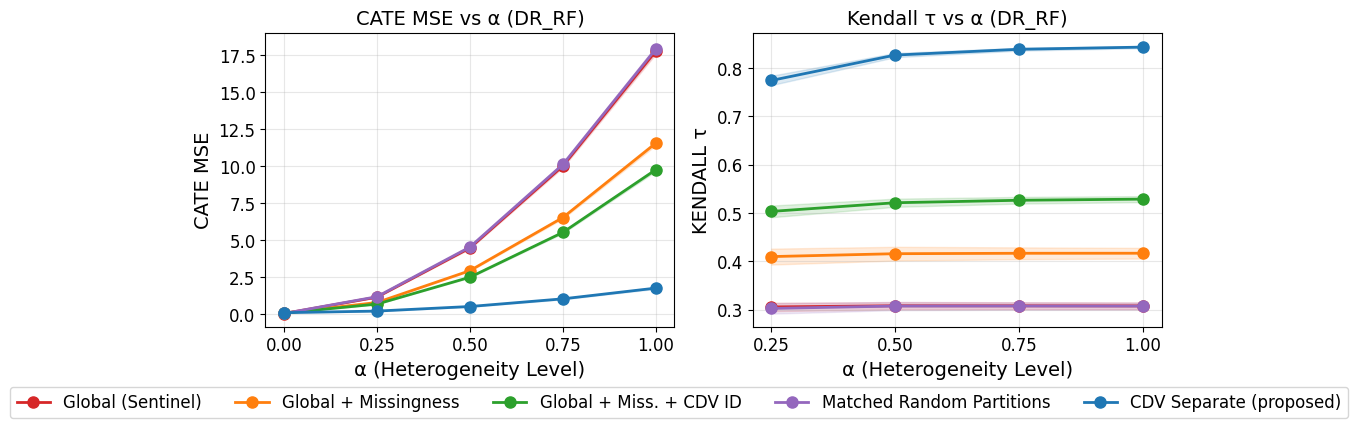

In [20]:
from helpers.plotting import plot_scissors_chart_combined

fig = plot_scissors_chart_combined(
    results_by_alpha,
    panels=[
        {'metric': 'cate_mse', 'alpha_values': CFG.ALPHA_VALUES,
         'title': f'CATE MSE vs α ({CFG.PRIMARY_LEARNER})'},
        {'metric': 'kendall_tau', 'alpha_values': [a for a in CFG.ALPHA_VALUES if a > 0],
         'title': f'Kendall τ vs α ({CFG.PRIMARY_LEARNER})'},
    ],
    learner=CFG.PRIMARY_LEARNER,
    save_path=os.path.join(CFG.PLOTS_DIR, 'combined_cate_kendall.png'),
)
plt.show()
